## Glacier Mass Balance Workflow / Flujo de Balance de Masa

### English
This pipeline computes and maps **glacier mass balance (MB)** on a grid built from **topographic** and **ERA5 climate** data, aggregated to **annual means per (lon, lat) cell** and masked by the glacier polygon.

**Steps**
1. **Load & clean** CSV of topographic features (`CL_topographical_features.csv`) → `data.dropna()`.
2. **MBM setup**: create `cfg`, build `mbm.Dataset`, and **match ERA5 variables** (`t2m, tp, slhf, sshf, ssrd, fal, str`) + **topography** (`aspect, slope`).
3. **Monthly conversion**: `dataset.convert_to_monthly(...)`.
4. **Select glacier** (`RGI60-17.12440`) and **OGGM mask**: `get_glacier_mask(...)`.
5. **Build glacier grid** for target years (e.g., 2020–2023): `create_glacier_grid_RGI(...)`; keep relevant metadata columns.
6. **Load monthly grid dataset** (`..._monthly_dataset.csv`), clean, and optionally **analyze MB by elevation bands**.
7. **Annual mean per cell** (preserves spatial grid):  
   `data_mean = df.groupby(['YEAR','POINT_LON','POINT_LAT'], as_index=False)['MB'].mean()`
8. **Map per year**:
   - Interpolate MB field (`scipy.interpolate.griddata`, `method='cubic'`)
   - **Rasterize** and **mask** with glacier polygon (`rasterio.features.rasterize`)
   - Plot multi-panel (one map per year) with **zero-centered colormap** (blue = accumulation, red = ablation) and **contours**
   - Save figure: `mass_balance_multiyear_map.png`

**Notes**
- Ensure shapefile CRS matches point coords (WGS84/EPSG:4326).

**Dependencies**
`pandas`, `numpy`, `matplotlib`, `seaborn`, `geopandas`, `scipy`, `rasterio`, `shapely`, `affine`, `massbalancemachine (mbm)`, `OGGM helpers`.

---

### Español 
Este flujo calcula y mapea el **balance de masa (MB)** glaciar en una grilla construida con datos **topográficos** y **climáticos ERA5**, agregados a **medias anuales por celda (lon, lat)** y recortados por el polígono del glaciar.

**Pasos**
1. **Cargar y limpiar** CSV de topografía (`CL_topographical_features.csv`) → `data.dropna()`.
2. **Configurar MBM**: crear `cfg`, construir `mbm.Dataset` y **asignar variables ERA5** (`t2m, tp, slhf, sshf, ssrd, fal, str`) + **topografía** (`aspect, slope`).
3. **Convertir a mensual**: `dataset.convert_to_monthly(...)`.
4. **Seleccionar glaciar** (`RGI60-17.12440`) y **máscara OGGM**: `get_glacier_mask(...)`.
5. **Crear grilla del glaciar** para años objetivo (p. ej. 2020–2023): `create_glacier_grid_RGI(...)`; conservar metadatos relevantes.
6. **Cargar dataset mensual de grilla** (`..._monthly_dataset.csv`), limpiar y opcionalmente **analizar MB por bandas de elevación**.
7. **Media anual por celda** (mantiene la espacialidad):  
   `data_mean = df.groupby(['YEAR','POINT_LON','POINT_LAT'], as_index=False)['MB'].mean()`
8. **Mapas por año**:
   - Interpolar campo MB (`scipy.interpolate.griddata`, `method='cubic'`)
   - **Rasterizar** y **enmascarar** con el polígono del glaciar (`rasterio.features.rasterize`)
   - Graficar multipanel (un mapa por año) con **escala centrada en cero** (azul = acumulación, rojo = ablación) y **contornos**
   - Guardar figura: `mass_balance_multiyear_map.png`

**Notas**
- Omitir años con pocas muestras (p. ej., `< 5` puntos). Si hay huecos, usar `method='linear'`.
- Asegurar que el CRS del shapefile coincida con las coordenadas (WGS84/EPSG:4326).

**Dependencias**
`pandas`, `numpy`, `matplotlib`, `seaborn`, `geopandas`, `scipy`, `rasterio`, `shapely`, `affine`, `massbalancemachine (mbm)`, `OGGM helpers`.

In [17]:
#Load Packages
import pandas as pd
import massbalancemachine as mbm
import warnings
import geopandas as gpd
import numpy as np
from massbalancemachine.data_processing.create_glacier_grid import create_glacier_grid_RGI
from massbalancemachine.data_processing.get_topo_data import get_glacier_mask

warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


1. Load and Prepare Glacier Dataset / Cargar y preparar el dataset glaciar

In [59]:

# Specify the input file name that contains the RGIId list  
# Especifique el nombre del archivo de entrada que contiene la lista de RGIId
glas_fname = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/files/CL_topographical_features.csv'

# Load the CSV file into a pandas DataFrame  
# Cargue el archivo CSV en un DataFrame de pandas
data = pd.read_csv(glas_fname)

# Remove rows with missing values and reset the index  
# Elimine filas con valores faltantes y reinicie el índice
data = data.dropna().reset_index(drop=True)

# Create a Mass Balance Machine configuration object  
# Cree un objeto de configuración para Mass Balance Machine
cfg = mbm.Config()
#cfg = mbm.ConfigChile() # Just for Chile
display(data)


# Get the list of unique RGI Ids to avoid duplicates  
# Obtenga la lista de RGI Id únicos para evitar duplicados
rgi_gl = data.RGIId.unique()
print(rgi_gl)

,POINT_ID,FROM_DATE,TO_DATE,POINT_LON,POINT_LAT,POINT_ELEVATION,POINT_BALANCE,YEAR,RGIId,aspect,slope
0,B1,20211024,20220604,-71.413294,-36.834797,2850.216,-11.340,2022.0,RGI60-17.13045,4.722618,0.446868
1,B2,20220115,20220604,-71.412119,-36.834306,2884.160,-12.580,2022.0,RGI60-17.13045,4.722618,0.446868
2,B3,20211024,20220604,-71.414980,-36.837341,2747.150,-8.670,2022.0,RGI60-17.13045,4.722618,0.446868
3,B4,20211024,20220604,-71.414161,-36.836079,2795.900,-12.390,2022.0,RGI60-17.13045,4.722618,0.446868
4,B5,20211024,20220604,-71.414799,-36.835262,2813.830,-3.430,2022.0,RGI60-17.13045,4.722618,0.446868
...,...,...,...,...,...,...,...,...,...,...,...
698,1,20210804,20211215,-73.173000,-46.510000,184.000,-16.178,2021.0,RGI60-17.15831,3.390379,0.241352
699,2,20210804,20211215,-73.177000,-46.509000,195.000,-18.030,2021.0,RGI60-17.15831,3.390379,0.241352
700,3,20210804,20211215,-73.175000,-46.513000,187.000,-15.314,2021.0,RGI60-17.15831,3.390379,0.241352
701,4,20210804,20211215,-73.174000,-46.518000,175.000,-15.067,2021.0,RGI60-17.15831,3.390379,0.241352


['RGI60-17.13045' 'RGI60-17.14887' 'RGI60-17.14088' 'RGI60-17.01218'
 'RGI60-17.12442' 'RGI60-17.12440' 'RGI60-17.13715' 'RGI60-17.15831']


2. Load Glacier Topography and Create Synthetic Grid / Cargar topografía glaciar y crear grilla sintética

In [68]:
# Select data for a specific glacier using its RGI Id  
# Seleccione datos para un glaciar específico usando su RGI Id
rgiid='RGI60-17.12440'
data1 = data[data.RGIId==rgiid]

# Define the directory where OGGM glacier data (with topographic info) is stored  
# Defina el directorio donde se almacena la información topográfica de los glaciares OGGM
custom_working_dir='/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/input/OGGM_mocho/'
ds, glacier_indices, gdir = get_glacier_mask(data1, custom_working_dir=custom_working_dir, cfg=cfg)

# Define the simulation period in years  
# Defina el período de simulación en años
years = range(2020, 2024)

# Create a DataFrame with a synthetic glacier grid for the given years  
# Cree un DataFrame con una grilla sintética del glaciar para los años especificados
df_grid = create_glacier_grid_RGI(ds, years, glacier_indices, gdir,
                                rgi_gl[rgi_gl==rgiid])

# Just for Chile
""" def classify_region(lat):
    if -31 <= lat < -17:
        return "Desert Andes"
    elif -36 <= lat < -31:
        return "Central Andes"
    elif -45 <= lat < -36:
        return "North Patagonian Andes"
    elif -55 <= lat < -45:
        return "South Patagonian Andes"
    else:
        return "Outside range"


# Create new attribute
df_grid["region"] = df_grid["POINT_LAT"].apply(classify_region)

var_topo = ['YEAR', 'RGIId', 'POINT_LAT', 'POINT_LON', 'aspect', 'slope',
            'POINT_ELEVATION', 'POINT_BALANCE',
            'FROM_DATE', 'TO_DATE','region']
data_glas =  df_grid[var_topo] """

# Keep only the selected topographical and metadata variables  
# Mantenga solo las variables topográficas y de metadatos seleccionadas
var_topo = ['YEAR', 'RGIId', 'POINT_LAT', 'POINT_LON', 'aspect', 'slope',
            'POINT_ELEVATION', 'POINT_BALANCE',
            'FROM_DATE', 'TO_DATE']
data_glas =  df_grid[var_topo]
data_glas['POINT_ID'] = data_glas['RGIId']


2025-08-19 10:54:57: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-08-19 10:54:57: oggm.cfg: Multiprocessing switched OFF according to the parameter file.


2025-08-19 10:54:57: oggm.cfg: Multiprocessing: using all available processors (N=40)
2025-08-19 10:54:57: oggm.cfg: PARAMS['border'] changed from `80` to `10`.
2025-08-19 10:54:57: oggm.cfg: Multiprocessing switched ON after user settings.
2025-08-19 10:54:57: oggm.cfg: PARAMS['continue_on_error'] changed from `False` to `True`.
2025-08-19 10:54:58: oggm.workflow: init_glacier_directories from prepro level 3 on 1 glaciers.
2025-08-19 10:54:58: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers
2025-08-19 10:54:59: oggm.workflow: Execute entity tasks [gridded_attributes] on 1 glaciers


3. Create Mass Balance Machine Dataset and Extract Climate Features / Crear dataset para Mass Balance Machine y extraer variables climáticas

In [72]:
# Create a Dataset object for the glacier, specifying its RGIId column  
# Cree un objeto Dataset para el glaciar, especificando su columna RGIId
dataset = mbm.Dataset(cfg=cfg, data=data_glas, region_name='CL_mocho_g1_grid_2013', data_path='/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/files/')

# Specify the climate data files that match glacier coordinates  
# Especifique los archivos de datos climáticos que coincidan con las coordenadas del glaciar
era5_climate_data = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/input/ERA5/CL_era5_monthly_averaged_data.nc'
geopotential_data = '/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/input/ERA5/geopotential/era5_geopotential_pressure.nc'

# Match ERA5 climate features to each glacier stake measurement  
# Haga coincidir las variables climáticas de ERA5 para cada medición de estaca glaciar
dataset.get_climate_features(climate_data=era5_climate_data, geopotential_data=geopotential_data) 

# Define the short names of the variables to extract  
# Defina los nombres cortos de las variables a extraer
vois_climate = ['t2m', 'tp', 'slhf', 'sshf', 'ssrd', 'fal', 'str']
voi_topographical = ['aspect', 'slope']

# Convert all records to a monthly time resolution  
# Convierta todos los registros a una resolución de tiempo mensual
dataset.convert_to_monthly(vois_climate=vois_climate, vois_topographical=voi_topographical)

4. Load Glacier Monthly Dataset and Configuration / Cargar dataset glaciar mensual y configuración

In [73]:
import pandas as pd
import massbalancemachine as mbm
import warnings
#import matplotlib.pyplot as plt
import numpy as np
from joblib import load

warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

# Load the glacier dataset containing predictor variables for MB estimation
# Cargar el dataset glaciar con variables predictoras para la estimación del MB 
data = pd.read_csv('/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/files/CL_mocho_g1_grid_2013_monthly_dataset.csv')
print('Number of grids:', len(data))
display(data)

# Remove missing values and reset index
# Eliminar valores faltantes y reiniciar el índice
data = data.dropna().reset_index(drop=True)

# Initialize Mass Balance Machine configuration
# Inicializar configuración del Mass Balance Machine
cfg=mbm.Config()
# cfg = mbm.ChileConfig() # Just for Chile

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of grids: 162032


,YEAR,POINT_LON,POINT_LAT,POINT_BALANCE,ALTITUDE_CLIMATE,ELEVATION_DIFFERENCE,POINT_ELEVATION,RGIId,POINT_ID,ID,...,MONTHS,aspect,slope,t2m,tp,slhf,sshf,ssrd,fal,str
0,2020,-72.021648,-39.929145,0,908.334473,1285.665527,2194.0,['RGI60-17.12440'],['RGI60-17.12440'],0,...,sep,1.281520,0.388505,276.683838,0.005615,-1795019.0,-1448796.0,1.393611e+07,0.328019,-3581022.0
1,2020,-72.021648,-39.929145,0,908.334473,1285.665527,2194.0,['RGI60-17.12440'],['RGI60-17.12440'],0,...,oct,1.281520,0.388505,279.096436,0.005586,-5674076.0,-3892681.0,1.878662e+07,0.190914,-4536070.0
2,2020,-72.021648,-39.929145,0,908.334473,1285.665527,2194.0,['RGI60-17.12440'],['RGI60-17.12440'],0,...,nov,1.281520,0.388505,282.856445,0.005391,-8356527.0,-4847536.0,2.170447e+07,0.141770,-4690550.0
3,2020,-72.021648,-39.929145,0,908.334473,1285.665527,2194.0,['RGI60-17.12440'],['RGI60-17.12440'],0,...,dec,1.281520,0.388505,284.962891,0.002612,-9648672.0,-6907518.0,2.673842e+07,0.131304,-5850822.0
4,2020,-72.021648,-39.929145,0,908.334473,1285.665527,2194.0,['RGI60-17.12440'],['RGI60-17.12440'],0,...,jan,1.281520,0.388505,287.443359,0.002841,-10266158.0,-6111560.0,2.600979e+07,0.121098,-5989622.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
162027,2023,-72.027444,-39.962796,0,908.334473,774.665527,1683.0,['RGI60-17.12440'],['RGI60-17.12440'],12463,...,may,3.166448,0.162287,278.193115,0.004971,-623884.0,-204468.0,2.193098e+06,0.171021,-1342332.5
162028,2023,-72.027444,-39.962796,0,908.334473,774.665527,1683.0,['RGI60-17.12440'],['RGI60-17.12440'],12463,...,jun,3.166448,0.162287,275.172363,0.009622,-380145.5,23113.5,1.472045e+06,0.239821,-774489.0
162029,2023,-72.027444,-39.962796,0,908.334473,774.665527,1683.0,['RGI60-17.12440'],['RGI60-17.12440'],12463,...,jul,3.166448,0.162287,273.827881,0.007828,-122522.0,-78059.0,1.635487e+06,0.330675,-853236.5
162030,2023,-72.027444,-39.962796,0,908.334473,774.665527,1683.0,['RGI60-17.12440'],['RGI60-17.12440'],12463,...,aug,3.166448,0.162287,273.929199,0.007255,-354831.5,-337351.0,2.536432e+06,0.299262,-1211068.0


5. Load Trained Neural Network Model and Prepare Features / Cargar modelo de red neuronal entrenado y preparar variables

In [74]:
# Load the best trained NN model for the glacier and set it to run on CPU
# Cargar el mejor modelo entrenado para el glaciar y configurarlo para ejecutarse en CPU
NN_model = load('/home/duilio/github/MassBalanceMachine/regions/Chile/models/model_nn_mocho.pkl')
nn = NN_model.best_estimator_.set_params(device='cpu')

# Create features and metadata from dataset
# Crear variables predictoras y metadatos desde el dataset
features, metadata = nn._create_features_metadata(data)

# Identify predictor columns by excluding metadata and non-feature columns
# Identificar columnas predictoras excluyendo metadatos y columnas no útiles
feature_columns = data.columns.difference(cfg.metaData)
feature_columns = feature_columns.drop(cfg.notMetaDataNotFeatures)
feature_columns = list(feature_columns)

# Get min/max bounds for each feature for normalization
# Obtener límites mínimo/máximo de cada variable para normalización
bounds_features = {k:(np.min(data[k].values), np.max(data[k].values)) for k in feature_columns}

# Create normalizer and apply to features
# Crear normalizador y aplicarlo a las variables
norm = mbm.data_processing.Normalizer(bounds_features)
norm_features = norm.normalize(features)



6. Predict Mass Balance (MB) Using Neural Network Model / Predecir balance de masa (MB) usando el modelo de red neurona

In [75]:
# Predict MB for each grid point using normalized features
# Predecir MB para cada punto de grilla usando variables normalizadas
data['MB'] = nn.predict(norm_features)


7. Annual Mass Balance Analysis by Elevation Bands / Análisis anual del balance de masa por bandas de elevación

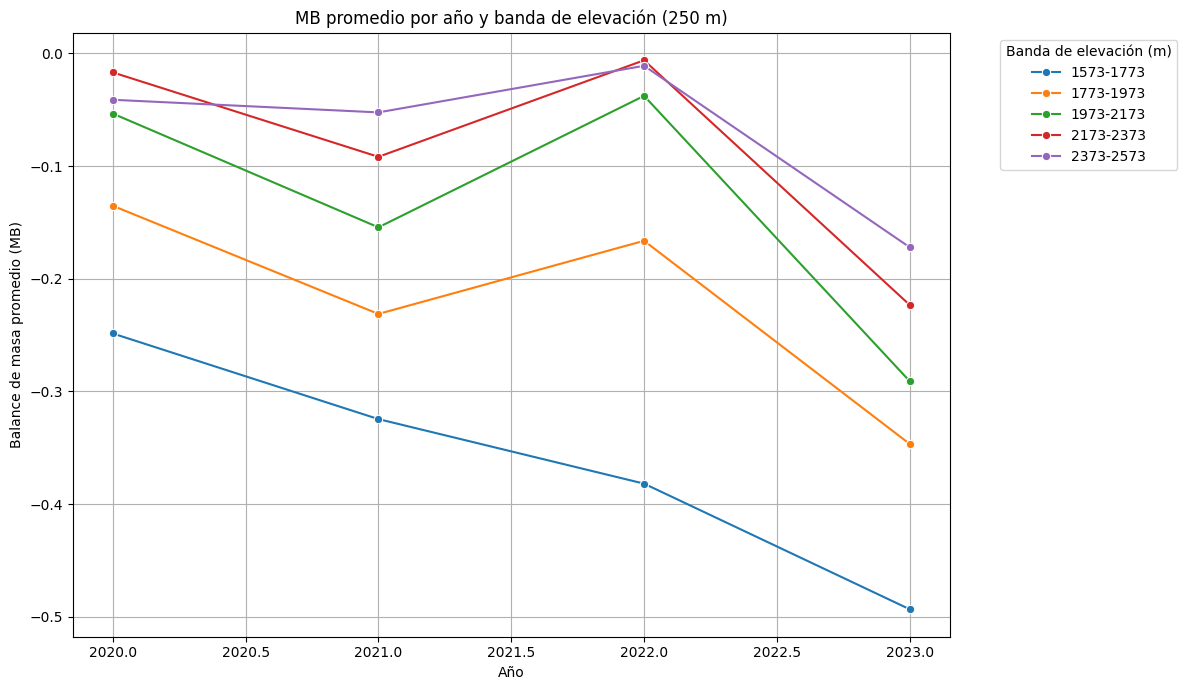

In [76]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Copy data to avoid modifying the original DataFrame
# Copiar datos para no modificar el DataFrame original
df = data.copy()
intervalo = 200  # Elevation band interval in meters / Intervalo de banda de elevación en metros

# Determine elevation range
# Determinar el rango de elevación
elev_min = df['POINT_ELEVATION'].min()
elev_max = df['POINT_ELEVATION'].max()

# Create elevation band column
# Crear columna de banda de elevación
df['elev_band'] = pd.cut(
    df['POINT_ELEVATION'],
    bins=np.arange(elev_min, elev_max + intervalo, intervalo),
    labels=[f"{int(b)}-{int(b+intervalo)}" for b in np.arange(elev_min, elev_max, intervalo)],
    include_lowest=True
)

# Group by year and elevation band, calculating mean MB
# Agrupar por año y banda de elevación, calculando MB promedio
df_grouped = df.groupby(['YEAR', 'elev_band'])['MB'].mean().reset_index()

# Plot with circular markers
# Graficar con marcadores circulares
plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_grouped,
    x='YEAR',
    y='MB',
    hue='elev_band',
    marker='o'
)

plt.title("MB promedio por año y banda de elevación (250 m)")
plt.xlabel("Año")
plt.ylabel("Balance de masa promedio (MB)")
plt.legend(title="Banda de elevación (m)", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.savefig("mass_balance_bandas.png", dpi=200)
plt.show()


8. Monthly Global Mass Balance Time Series / Serie temporal global mensual del balance de masa

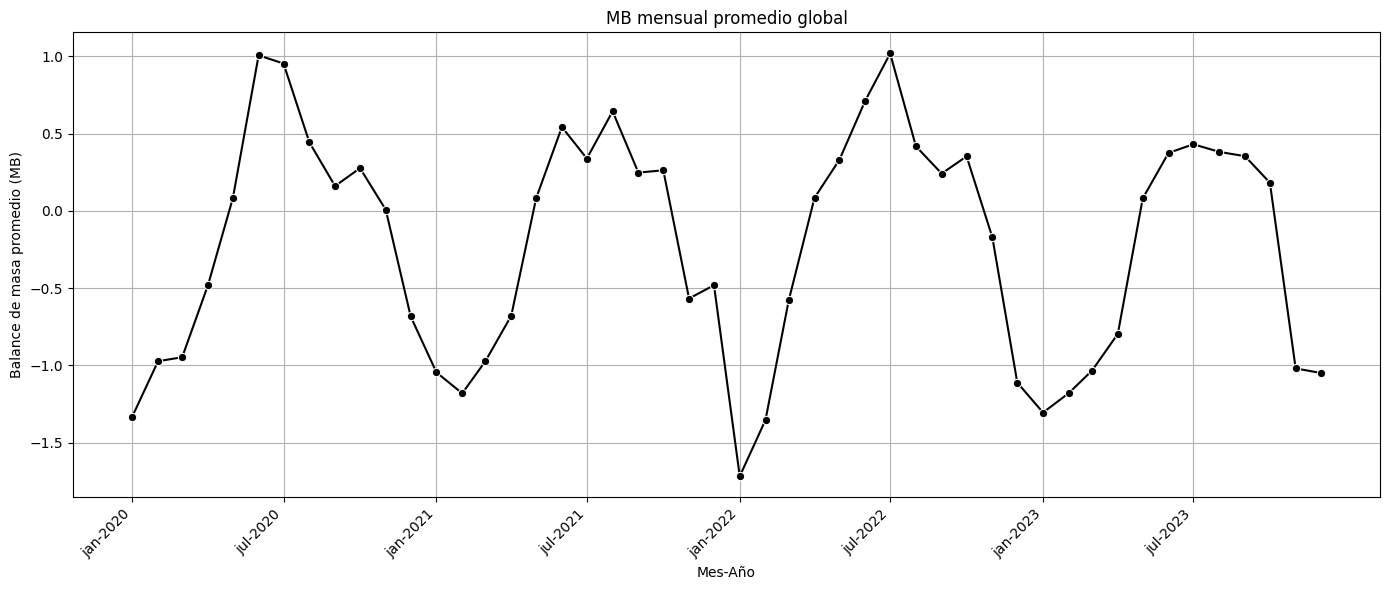

In [77]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# copiar datos
df = data.copy()

# Ensure correct format for MONTHS and YEAR
# Asegurar formato correcto para MONTHS y YEAR
df['MONTHS'] = df['MONTHS'].str.lower()
df['YEAR'] = df['YEAR'].astype(int)

# Build date strings and convert to datetime
# Construir cadenas de fecha y convertir a datetime
df['MES_ANO_STR'] = df['MONTHS'] + '-' + df['YEAR'].astype(str)
df['MONTHS_DT'] = pd.to_datetime(df['MES_ANO_STR'], format='%b-%Y', errors='coerce')


# Remove invalid dates
# Eliminar fechas inválidas
df = df.dropna(subset=['MONTHS_DT'])

# Create label for x-axis ticks
# Crear etiqueta para ticks del eje X
df['MES_ANO'] = df['MONTHS_DT'].dt.strftime('%b-%Y').str.lower()

# Group by date and calculate mean MB
# Agrupar por fecha y calcular MB promedio
df_grouped = df.groupby(['MONTHS_DT', 'MES_ANO'])['MB'].mean().reset_index()

# Plot time series
# Graficar serie temporal
plt.figure(figsize=(14, 6))
sns.lineplot(
    data=df_grouped,
    x='MONTHS_DT',
    y='MB',
    marker='o',
    color='black'
)

plt.title("MB mensual promedio global")
plt.xlabel("Mes-Año")
plt.ylabel("Balance de masa promedio (MB)")

# xticks cada 6 meses
xtick_pos = df_grouped['MONTHS_DT'].iloc[::6]
xtick_labels = df_grouped['MES_ANO'].iloc[::6]
plt.xticks(ticks=xtick_pos, labels=xtick_labels, rotation=45, ha='right')

plt.grid(True)
plt.tight_layout()
plt.savefig("mass_balance_mensual_global.png", dpi=200)
plt.show()



9. Spatial Interpolation and Mapping of Mass Balance by Year /Interpolación espacial y mapeo del balance de masa por año

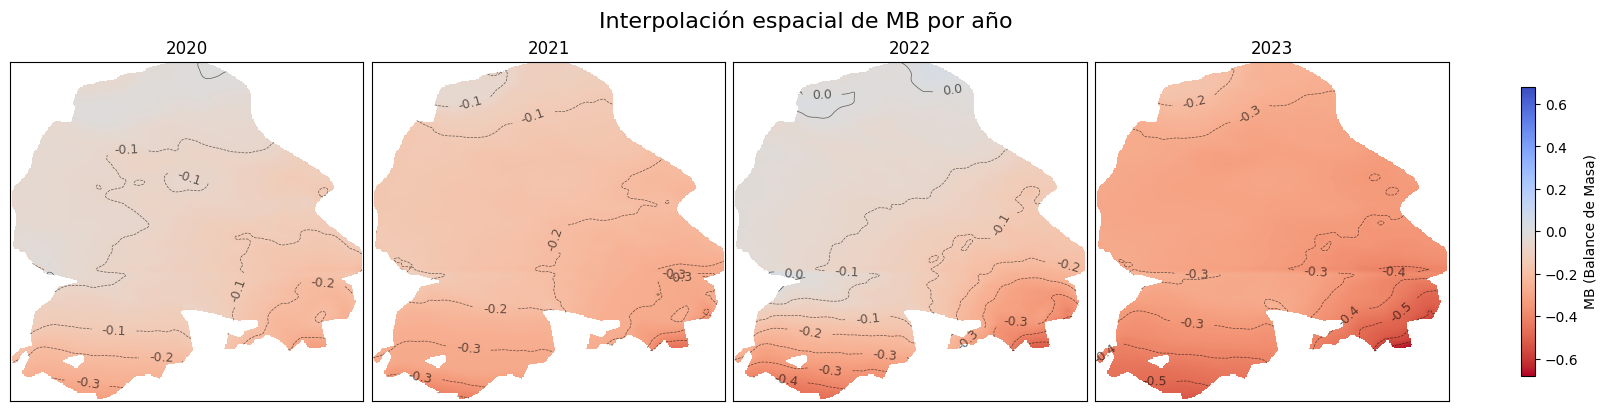

In [82]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from scipy.interpolate import griddata
from shapely.geometry import Point
from rasterio import features
from affine import Affine
import os

# Load glacier shapefile and select specific glacier polygon
# Cargar shapefile del glaciar y seleccionar el polígono específico
shapefile_path = r"/mnt/d/Investigadores/Duilio.Fonseca/Machine-Learning/data/input/shapes/RGI_mocho/17_rgi60_SouthernAndes.shp"
gdf = gpd.read_file(shapefile_path)
glacier_shape = gdf[gdf['RGIId'] == 'RGI60-17.12440']


data_mean = (
    df.groupby(['YEAR', 'POINT_LON', 'POINT_LAT'], as_index=False)['MB']
      .mean()
)
data_mean

# Determine color scale symmetric around zero (blue = accumulation, red = ablation)
# Definir escala de color centrada en cero (azul = acumulación, rojo = ablación)
zmin = data_mean['MB'].min()
zmax = data_mean['MB'].max()
abs_max = max(abs(zmin), abs(zmax))

# Get list of years available
# Obtener lista de años disponibles
years = sorted(data_mean['YEAR'].unique())

# Define subplot grid layout
# Definir la grilla de subplots
n_cols = 4
n_rows = int(np.ceil(len(years) / n_cols))

# Create overall figure
# Crear figura general
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)
axes = axes.flatten()

for idx, year_to_plot in enumerate(years):
    data_year = data_mean[data_mean['YEAR'] == year_to_plot]

    # Skip years with too few data points
    # Saltar años con pocos datos
    if len(data_year) < 5:
        continue

    # Extract coordinates and MB values
    # Extraer coordenadas y valores de MB
    x = data_year['POINT_LON'].values
    y = data_year['POINT_LAT'].values
    z = data_year['MB'].values

    # Create interpolation grid
    # Crear grilla de interpolación
    xi = np.linspace(x.min(), x.max(), 300)
    yi = np.linspace(y.min(), y.max(), 300)
    xi, yi = np.meshgrid(xi, yi)

    # Interpolate MB values on the grid
    # Interpolar valores de MB sobre la grilla
    zi = griddata((x, y), z, (xi, yi), method='cubic')

    # Rasterize glacier polygon for masking
    # Rasterizar el polígono glaciar para enmascarar
    res_x = (x.max() - x.min()) / (xi.shape[1] - 1)
    res_y = (y.max() - y.min()) / (yi.shape[0] - 1)
    transform = Affine.translation(x.min() - res_x / 2, y.min() - res_y / 2) * Affine.scale(res_x, res_y)

    mask = features.rasterize(
        [(geom, 1) for geom in glacier_shape.geometry],
        out_shape=zi.shape,
        transform=transform,
        fill=0,
        dtype=np.uint8
    )

    # Apply mask and remove NaNs
    # Aplicar máscara y eliminar NaN
    zi_masked = np.ma.masked_where((mask == 0) | np.isnan(zi), zi)

    # Plot MB map in the corresponding subplot
    # Graficar el mapa de MB en el subplot correspondiente
    ax = axes[idx]
    im = ax.imshow(
        zi_masked,
        extent=(x.min(), x.max(), y.min(), y.max()),
        origin='lower',
        cmap='coolwarm_r',
        vmin=-abs_max,
        vmax=abs_max,
        aspect='auto'
    )

    # Draw contour lines
    # Dibujar líneas de contorno
    contour_levels = np.linspace(-abs_max, abs_max, 21)
    contours = ax.contour(
        xi, yi, zi_masked,
        levels=contour_levels,
        colors='black',
        linewidths=0.5,
        alpha=0.6
    )
    ax.clabel(contours, inline=True, fontsize=9, fmt='%.1f')
    ax.set_title(f"{year_to_plot}")
    ax.set_xticks([])
    ax.set_yticks([])

# Remove empty subplots if needed
# Eliminar subplots vacíos si es necesario
for j in range(idx + 1, len(axes)):
    fig.delaxes(axes[j])

# Add global colorbar
# Agregar barra de color global
cbar = fig.colorbar(im, ax=axes, orientation='vertical', shrink=0.85, label='MB (Balance de Masa)')

# Save final figure
# Guardar figura final
plt.suptitle("Interpolación espacial de MB por año", fontsize=16)
plt.savefig("mass_balance_multiyear_map.png", dpi=200)
plt.show()


